In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from xgboost import XGBRegressor

import shap

In [3]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [4]:
# df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_One_Day_Prediction_New.csv", index_col="time", parse_dates=True)
# df.info()

In [5]:
# df.head()

# Train And Test Split

In [6]:
# df.columns

In [7]:
# X = df.drop(columns = ['Day_1_Future_AQI'])
# Y = df['Day_1_Future_AQI']

In [8]:
# X

In [9]:
# Y

In [10]:
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [11]:
# len(X_train)

In [12]:
# len(X_test)

# Building XGBoost Model For Day One

In [13]:
# model = XGBRegressor(n_estimators = 520, 
#                      learning_rate = 0.033,
#                      # max_depth = 3, 
#                      random_state = 42, 
#                      colsample_bytree = 0.7, 
#                      subsample = 0.7,
#                      min_child_weight = 5,
#                      gamma=0.1,
#                      reg_alpha=0.1,
#                      reg_lambda=1.5,
#                     ) 

In [14]:
# model.fit(X_train, Y_train)

In [15]:
# y_pred = model.predict(X_test)

# Evaluating the Model

In [16]:
# R2_Score = r2_score(Y_test, y_pred)
# Mae = mean_absolute_error(Y_test, y_pred)
# Mean_Square_Error = mean_squared_error(Y_test, y_pred)
# Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

# print("Evaluation Metrics: ")
# print(f"R2 Score: {R2_Score}")
# print(f"Mean Absolute Error: {Mae}")
# print(f"Mean Square Error: {Mean_Square_Error}")
# print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [17]:
import os
from dotenv import load_dotenv
import hopsworks

os.makedirs("/tmp", exist_ok=True)

In [18]:
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("HOPSWORK_KEY")

In [19]:
project = hopsworks.login(
    project='aqi_karachi_samu_2026',
    host="eu-west.cloud.hopsworks.ai",
    port=443,
    api_key_value=key,
)

fs = project.get_feature_store()
print(f"Connected to {project.name}")

2026-08-23 00:31:44,140 INFO: Initializing external client
2026-08-23 00:31:44,141 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-23 00:31:48,263 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41193
Connected to aqi_karachi_samu_2026


In [20]:
target = "day_1_future_aqi"
day_1_fv = fs.get_feature_view(name="view_aqi_day1", version=1)

In [21]:
x, y = day_1_fv.training_data()

Reading data from Hopsworks, using Hopsworks Feature Query Service.     

2026-08-23 00:32:01,155 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.22s) 


In [22]:
day1 = x.copy()
day1[target] = y[target]

In [23]:
day1.time = pd.to_datetime(day1.time)
day1 = day1.sort_values("time").set_index("time")

In [24]:
day1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1092 entries, 2023-08-04 00:00:00+00:00 to 2026-07-30 00:00:00+00:00
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             1092 non-null   float64
 1   wind_speed_10m             1092 non-null   float64
 2   relative_humidity_2m       1092 non-null   float64
 3   surface_pressure           1092 non-null   float64
 4   boundary_layer_height      911 non-null    float64
 5   dew_point_2m               1092 non-null   float64
 6   precipitation              1092 non-null   float64
 7   cloud_cover                1092 non-null   float64
 8   wind_direction_10m         1092 non-null   float64
 9   wind_gusts_10m             1092 non-null   float64
 10  shortwave_radiation        1092 non-null   float64
 11  pm10                       1092 non-null   float64
 12  pm2_5                      1092 non-null   float64
 13  

In [25]:
day1.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,humidity_level,day_1_future_aqi
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,818.333333,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000,79.458333
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,900.416667,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500,78.833333
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,916.458333,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167,78.875000
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,805.416667,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000,78.791667
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,798.750000,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333,73.416667


# Train And Test Split

In [26]:
day1.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'day', 'month', 'dayofweek',
       'quarter', 'previous_hour_aqi', 'previous_day_aqi', 'aqi_change_rate',
       'rolled_mean_aqi_6hr', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_6hr', 'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr',
       'ewm_aqi_24hr', 'ewm_std_24hr', 'f24_temperature_2m',
       'f24_wind_speed_10m', 'f24_relative_humidity_2m',
       'f24_surface_pressure', 'f24_boundary_layer_height', 'f24_dew_point_2m',
       'f24_precipitation', 'f24_cloud_cover', 'f24_wind_gusts_10m',
       'f24_shortwave_radiation', 'wind_pollution_dispersion',
       'pressure_change_3

In [27]:
X1 = day1.drop(columns = [target])
Y1 = day1[target]

In [28]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_surface_pressure,f24_boundary_layer_height,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,humidity_level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,1002.600000,818.333333,24.866667,0.037500,69.833333,33.450000,220.291667,15605.187500,0.225000,3.150000
2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,1001.608333,900.416667,24.479167,0.029167,81.625000,45.562500,175.958333,18252.291667,0.266667,3.462500
2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,998.991667,916.458333,24.266667,0.070833,75.000000,49.770833,171.375000,27933.375000,-0.387500,3.754167
2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,999.362500,805.416667,24.512500,0.091667,68.541667,44.275000,172.000000,30741.333333,-0.200000,3.775000
2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,1002.587500,798.750000,24.487500,0.033333,72.916667,43.120833,220.875000,23936.687500,0.304167,3.483333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-26 00:00:00+00:00,29.687500,10.466667,73.000000,1000.854167,598.958333,24.254167,0.000000,78.416667,262.625000,27.916667,...,999.862500,770.208333,24.387500,0.004167,67.166667,35.854167,231.500000,6418.562500,0.050000,5.433333
2026-07-27 00:00:00+00:00,29.829167,14.262500,73.125000,999.862500,770.208333,24.387500,0.004167,67.166667,256.791667,35.854167,...,997.587500,736.041667,24.587500,0.012500,50.750000,39.495833,227.333333,11240.770833,-0.254167,5.441667
2026-07-28 00:00:00+00:00,29.450000,15.620833,75.458333,997.587500,736.041667,24.587500,0.012500,50.750000,244.333333,39.495833,...,997.862500,626.875000,25.458333,0.000000,68.041667,35.266667,246.125000,11677.250000,-0.137500,4.862500


In [29]:
Y1

time
2023-08-04 00:00:00+00:00    79.458333
2023-08-05 00:00:00+00:00    78.833333
2023-08-06 00:00:00+00:00    78.875000
2023-08-07 00:00:00+00:00    78.791667
2023-08-08 00:00:00+00:00    73.416667
                               ...    
2026-07-26 00:00:00+00:00    83.250000
2026-07-27 00:00:00+00:00    78.708333
2026-07-28 00:00:00+00:00    79.125000
2026-07-29 00:00:00+00:00    80.416667
2026-07-30 00:00:00+00:00    88.416667
Name: day_1_future_aqi, Length: 1092, dtype: float64

In [30]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [31]:
len(X_train1)

873

In [32]:
len(X_test1)

219

# Building XGBoost Model For Day One

In [33]:
model1 = XGBRegressor(n_estimators = 520, 
                     learning_rate = 0.033,
                     max_depth = 3, 
                     random_state = 42, 
                     colsample_bytree = 0.7, 
                     subsample = 0.7,
                     min_child_weight = 5,
                     gamma=0.1,
                     reg_alpha=0.1,
                     reg_lambda=1.5,
                    ) 

model1.fit(X_train1, Y_train1)
y_pred1 = model1.predict(X_test1)

# Evaluating the Model

In [34]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.8312631515789685
Mean Absolute Error: 5.507096120755968
Mean Square Error: 60.376927911584374
Root Mean Square Error: 7.770259192046581


# Baseline Prediction For Day One

In [35]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [36]:
R2_Score_baseline

0.5520268637872803

### So the Gain

In [37]:
R2_Score1 - R2_Score_baseline

0.2792362877916882

# Hyper Parameter Optimization Random Search 

In [38]:
random_grid = {
    "n_estimators": [
        150, 300, 500, 700, 900,
        1200, 1500, 1800, 1999
    ],
    "learning_rate": [
        0.005, 0.007, 0.01, 0.015,
        0.02, 0.03, 0.05, 0.07, 0.1
    ],
    "max_depth": [
        2, 3, 4, 5, 6, 7, 8
    ],
    "min_child_weight": [
        1, 2, 3, 4, 5, 7,
        10, 12, 15, 18, 20, 24
    ],
    "gamma": [
        0, 0.05, 0.1, 0.2, 0.4,
        0.6, 0.8, 1.0, 1.5, 2.0
    ],
    "subsample": [
        0.5, 0.55, 0.6, 0.65,
        0.7, 0.75, 0.8, 0.85,
        0.9, 0.95, 1.0
    ],
    "colsample_bytree": [
        0.5, 0.55, 0.6, 0.65,
        0.7, 0.75, 0.8, 0.85,
        0.9, 0.95, 1.0
    ],
    "reg_alpha": [
        0.001, 0.002, 0.005, 0.01,
        0.02, 0.05, 0.1, 0.2,
        0.5, 1, 2
    ],
    "reg_lambda": [
        0.1, 0.2, 0.5, 0.75,
        1, 1.5, 2, 3, 5, 7, 10
    ]
}

In [39]:
ts = TimeSeriesSplit(n_splits = 5, test_size = 90)

xg_random = RandomizedSearchCV(estimator = XGBRegressor(tree_method = 'hist', n_jobs =1, random_state =42),
                               param_distributions = random_grid,
                               n_iter = 100, 
                               cv = ts, 
                               random_state = 42,
                               n_jobs=-1)

xg_random.fit(X_train1, Y_train1)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.55, ...], 'gamma': [0, 0.05, ...], 'learning_rate': [0.005, 0.007, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl... test_size=90)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
def evaluate(model, test_features, test_labels):
  predictions = model.predict(test_features)
  r2 = r2_score(test_labels, predictions)
  mae1 = mean_absolute_error(test_labels, predictions)
  mse1 = mean_squared_error(test_labels, predictions)
  rmse1 = np.sqrt(mse1)
  print('Model Performance')
  print(f"R2 Score Fine Tuned Model: {r2}")
  print(f"Mean Absolute Error: {mae1}")
  print(f"Mean Square Error: {mse1}")
  print(f"Root Mean Square Error: {rmse1}")
  return r2

In [41]:
best_random = xg_random.best_estimator_
print(best_random)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.4, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1800,
             n_jobs=1, num_parallel_tree=None, ...)


In [42]:
random_accuracy = evaluate(best_random,X_test1,Y_test1)

Model Performance
R2 Score Fine Tuned Model: 0.8369990061841202
Mean Absolute Error: 5.369983075053363
Mean Square Error: 58.32454111375551
Root Mean Square Error: 7.6370505506874515


# SHAP STEP

### GET SHAP VALUES

In [43]:
explainer = shap.Explainer(best_random)
shap_values = explainer(X_test1)

### Waterfall Model

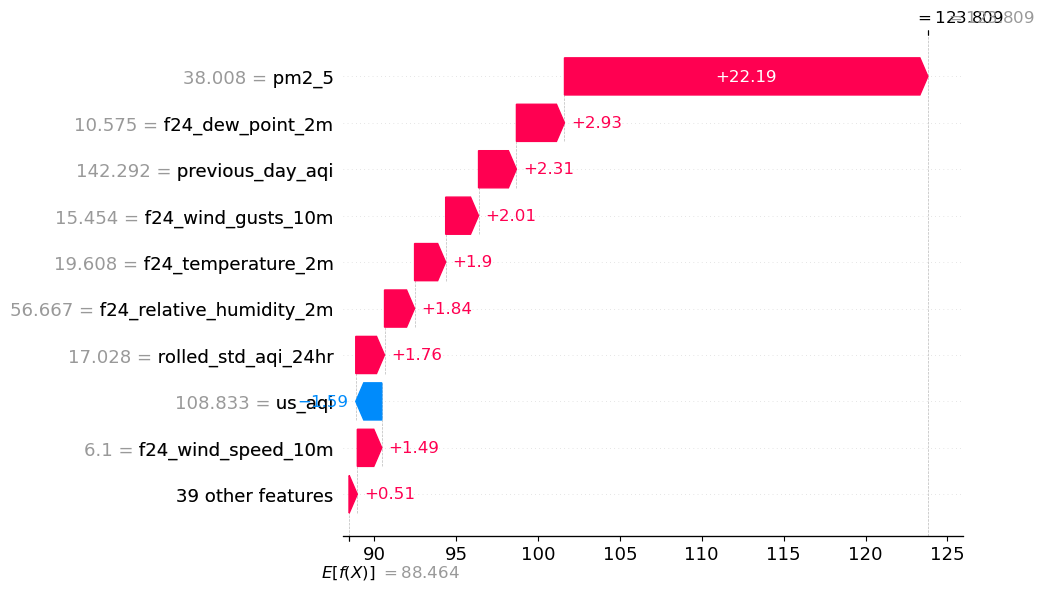

In [44]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

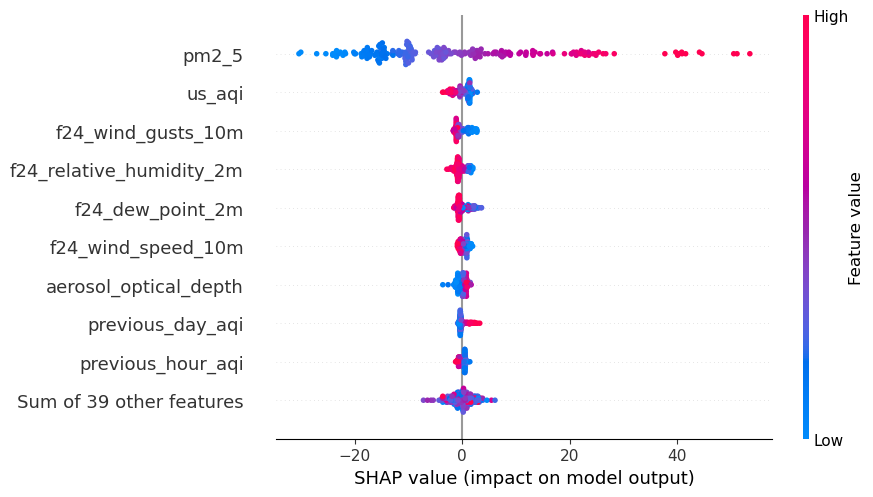

In [45]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

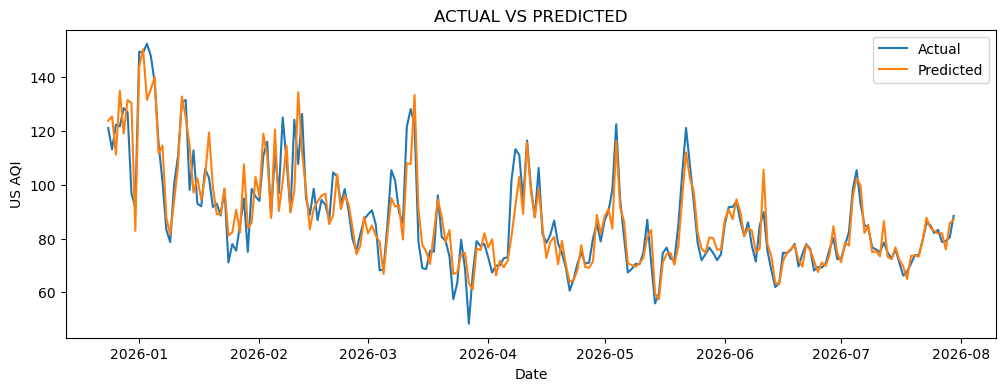

In [46]:
plt.figure(figsize=(12,4))
y_pred_tuned = best_random.predict(X_test1)
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, y_pred_tuned, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()

# Overfitting Test

In [47]:
train_Score = r2_score(Y_train1, best_random.predict(X_train1))
test_Score = r2_score(Y_test1, best_random.predict(X_test1))
print(f"Gap: {train_Score - test_Score}")

Gap: 0.16191524688269698
